In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
train_data, val_data, test_data = tfds.load(

def helper(ds):


train_images, train_labels = helper(train_data)
val_images, val_labels = helper(val_data)
test_images, test_labels = helper(test_data)

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
model = tf.keras.Sequential()


model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 32)                25120     
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 25,450
Trainable params: 25,450
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model.fit(

In [ ]:
plt.plot(history.history['loss'], label="training")
plt.plot(history.history['val_loss'], label="validation")
plt.legend()
plt.ylabel("loss")
plt.xlabel("epochs")

In [ ]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 2ms/step - loss: 0.4113 - accuracy: 0.8598


[0.4113401472568512, 0.8597999811172485]

In [ ]:
y_pred = model.predict(test_images)
y_pred = np.asarray([np.argmax(y) for y in y_pred])

313/313 [==============================] - 0s 1ms/step


## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
conf_mat = 

In [ ]:
fig, ax = plt.subplots(figsize=(15,10)) 
sns.heatmap

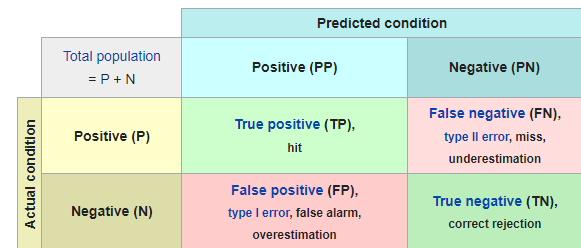

Source: https://en.wikipedia.org/wiki/Receiver_operating_characteristic

### **Precision**
$precision = \frac{TP} {TP + FP}$

### **Recall/Sensitivity/True positive rate**
$recall = \frac{TP} {TP + FN}$

### **Fall-out/False positive rate**
$fallout = \frac{FP} {FP + TN}$

### **Specificity/True negative rate**
$specificity = \frac{TN} {TN + FP}$

### **F1-score (harmonic mean of precision and recall)**
$F1 = \frac{2TP} {2TP + FP + FN}$


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, y_pred))

In [ ]:
# binarize labels to one-hot encoded vectors
from sklearn.preprocessing import LabelBinarizer

label_binarizer = 

(10000, 10)

In [ ]:
label_binarizer.transform([2])

array([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
# predict y_pred again
y_pred = model.predict(test_images)
y_pred[0]

313/313 [==============================] - 0s 1ms/step


array([0.09525519, 0.07554709, 0.11870797, 0.10281047, 0.09281901,
       0.10521749, 0.11596557, 0.10425135, 0.08158526, 0.10784063],
      dtype=float32)

## **ROC curves**

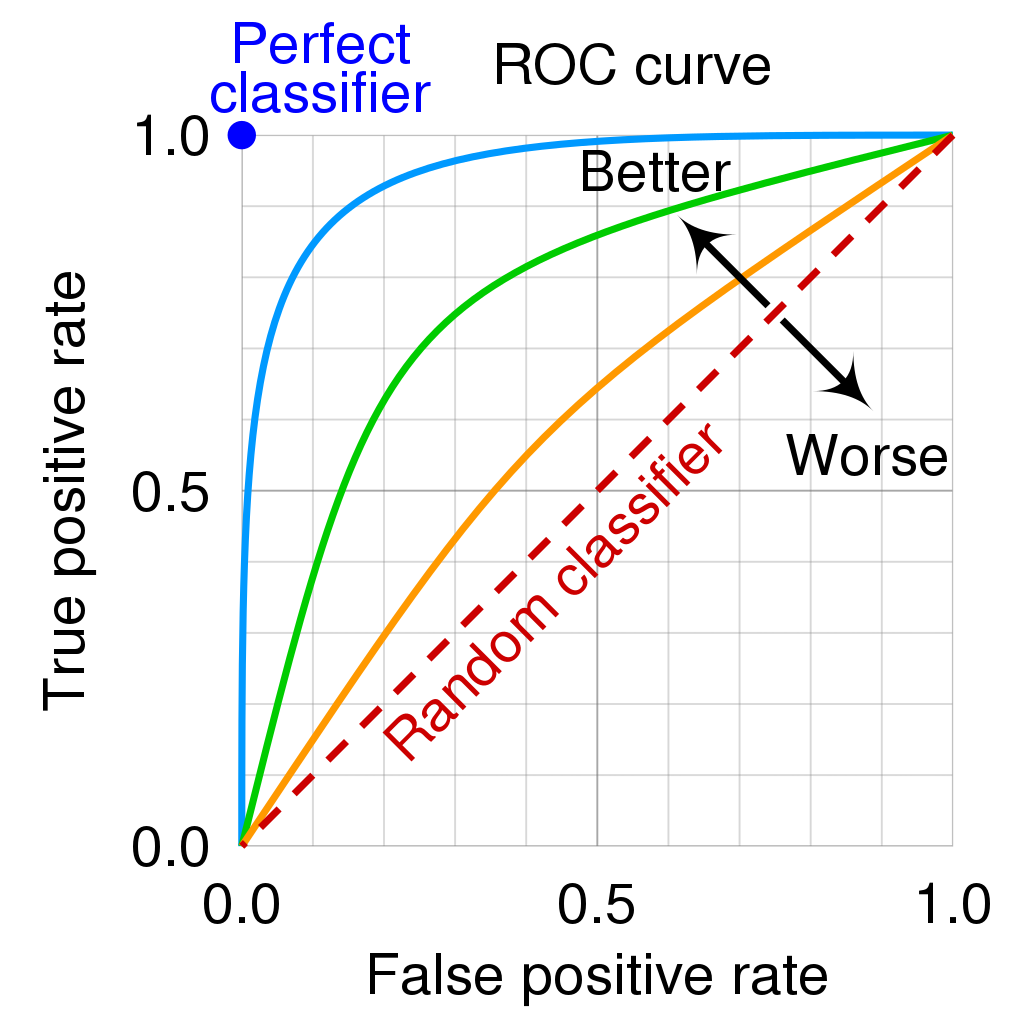

Source: https://en.wikipedia.org/wiki/Receiver_operating_characteristic#/media/File:Roc_curve.svg

In [ ]:
# display ROC curves
from sklearn.metrics import RocCurveDisplay

class_id = 6



plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC curves")
plt.legend()
plt.show()

## k-fold Cross Validation

In [ ]:
# Merge inputs and targets
inputs = np.concatenate((train_images, val_images, test_images), axis=0)
targets = np.concatenate((train_labels, val_labels, test_labels), axis=0)

inputs.shape

(70000, 28, 28, 1)

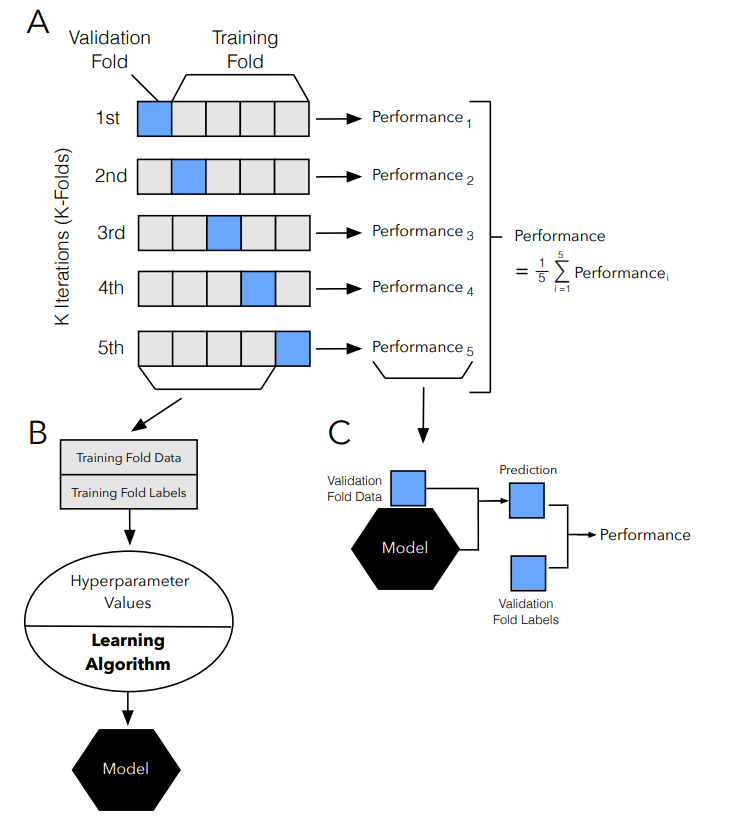

Source: https://arxiv.org/pdf/1811.12808.pdf

In [ ]:
from sklearn.model_selection import StratifiedKFold

kfold = 

In [ ]:
def get_model():
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
  model.add(tf.keras.layers.Dense(32, activation='relu'))
  model.add(tf.keras.layers.Dense(10, activation="softmax"))

  model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.975, decay=2e-06, nesterov=True),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
  return model

In [ ]:
acc_per_fold = []
loss_per_fold = []

for idx, (train, test) in enumerate(kfold.split(inputs, targets)):
  model = get_model()

  history = model.fit(inputs[train], targets[train], batch_size=128, epochs=10, verbose=0)
  scores = model.evaluate(inputs[test], targets[test])

  print(f'Score for fold {idx + 1}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
  acc_per_fold.append(scores[1] * 100)
  loss_per_fold.append(scores[0])